# Task 2 — Exploratory Data Analysis for Credit Risk Modeling

This notebook explores customer transaction behavior, data quality, feature distributions, and potential predictive patterns for downstream credit risk modeling.


## 1. Load Dataset

The dataset is loaded for initial exploration and quality assessment.


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/data.csv")


## 2. Dataset Overview

This section examines the structure, dimensions, and feature types within the dataset.


In [2]:
df.head()

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


In [3]:
df.shape

(95662, 16)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  object 
 1   BatchId               95662 non-null  object 
 2   AccountId             95662 non-null  object 
 3   SubscriptionId        95662 non-null  object 
 4   CustomerId            95662 non-null  object 
 5   CurrencyCode          95662 non-null  object 
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  object 
 8   ProductId             95662 non-null  object 
 9   ProductCategory       95662 non-null  object 
 10  ChannelId             95662 non-null  object 
 11  Amount                95662 non-null  float64
 12  Value                 95662 non-null  int64  
 13  TransactionStartTime  95662 non-null  object 
 14  PricingStrategy       95662 non-null  int64  
 15  FraudResult        

### Interpretation

The dataset contains transaction-level financial records with numerical, categorical, and temporal attributes suitable for behavioral analysis and downstream machine learning tasks.


## 3. Missing Value Analysis

This section checks for missing observations across all features.


In [5]:
df.isnull().sum()

TransactionId           0
BatchId                 0
AccountId               0
SubscriptionId          0
CustomerId              0
CurrencyCode            0
CountryCode             0
ProviderId              0
ProductId               0
ProductCategory         0
ChannelId               0
Amount                  0
Value                   0
TransactionStartTime    0
PricingStrategy         0
FraudResult             0
dtype: int64

### Interpretation

No missing values were detected across the dataset, indicating relatively strong data quality and reducing the need for aggressive imputation strategies.


## 4. Summary Statistics

Descriptive statistics help identify data distributions, variability, and potential outliers.


In [6]:
df.describe()

,CountryCode,Amount,Value,PricingStrategy,FraudResult
count,95662.0,9.566200e+04,9.566200e+04,95662.000000,95662.000000
mean,256.0,6.717846e+03,9.900584e+03,2.255974,0.002018
std,0.0,1.233068e+05,1.231221e+05,0.732924,0.044872
min,256.0,-1.000000e+06,2.000000e+00,0.000000,0.000000
25%,256.0,-5.000000e+01,2.750000e+02,2.000000,0.000000
50%,256.0,1.000000e+03,1.000000e+03,2.000000,0.000000
75%,256.0,2.800000e+03,5.000000e+03,2.000000,0.000000
max,256.0,9.880000e+06,9.880000e+06,4.000000,1.000000


### Interpretation

Transaction-related numerical features exhibit high variability and strong right-skewness, indicating the presence of extreme transaction values and substantial dispersion.


## 5. Numerical Feature Distribution

Distribution analysis helps identify skewness and transaction behavior patterns.


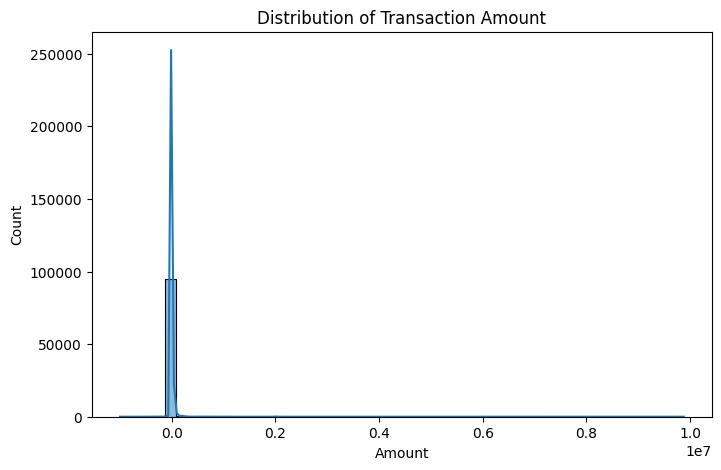

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df["Amount"], bins=50, kde=True)
plt.title("Distribution of Transaction Amount")
plt.show()


### Interpretation

The Amount feature is heavily right-skewed, indicating that most transactions are relatively small while a limited number of transactions account for extremely large values.


## 6. Outlier Detection

Boxplots help visualize extreme transaction behavior and outliers.


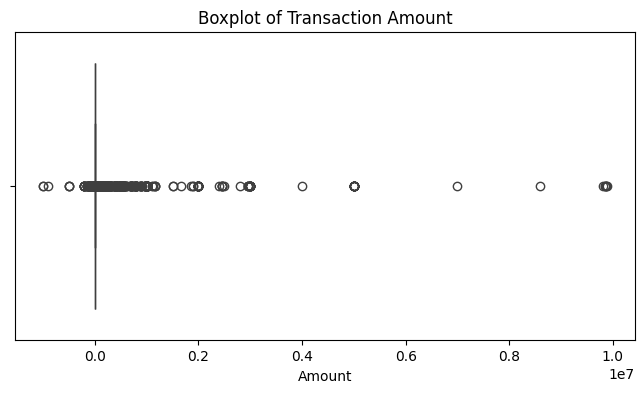

In [8]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Amount"])
plt.title("Boxplot of Transaction Amount")
plt.show()


### Interpretation

The boxplot confirms the presence of significant outliers in transaction amounts, suggesting the need for scaling or transformation before model training.


## 7. Fraud Distribution Analysis

This section examines the distribution of fraudulent and non-fraudulent transactions.


In [9]:
df["FraudResult"].value_counts()

FraudResult
0    95469
1      193
Name: count, dtype: int64

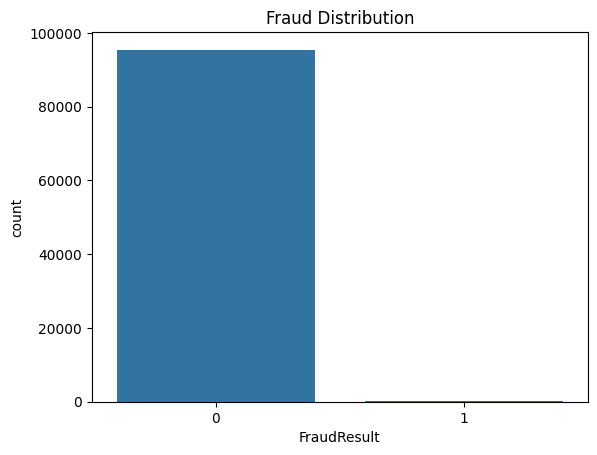

In [10]:
sns.countplot(x="FraudResult", data=df)
plt.title("Fraud Distribution")
plt.show()


### Interpretation

The fraud distribution is highly imbalanced, with fraudulent transactions representing only a very small fraction of the dataset.

This means accuracy alone would be misleading during model evaluation, making metrics such as Recall, F1-score, and ROC-AUC more important for assessing fraud detection performance.


## 8. Time-Based Feature Analysis

Temporal transaction patterns may provide useful behavioral insights.


In [11]:
df["TransactionStartTime"] = pd.to_datetime(df["TransactionStartTime"])

df["hour"] = df["TransactionStartTime"].dt.hour
df["day"] = df["TransactionStartTime"].dt.day
df["month"] = df["TransactionStartTime"].dt.month


### Interpretation

Time-based transaction patterns may help capture customer behavioral activity and engagement trends.


## 9. Correlation Analysis

Correlation analysis identifies relationships between numerical variables.


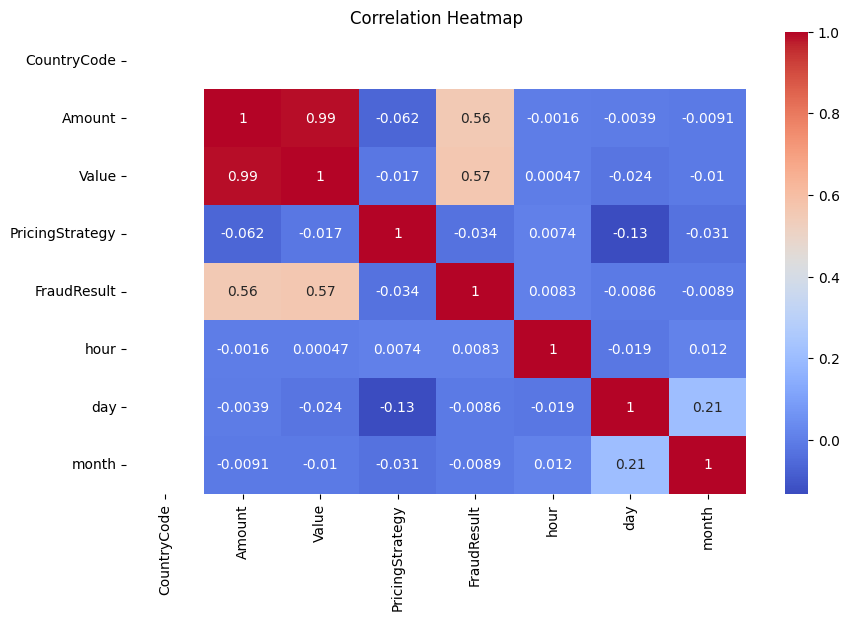

In [12]:
numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


### Interpretation

Strong correlation exists between certain monetary variables, suggesting possible redundancy and potential multicollinearity.


## 10. Customer-Level Behavioral Analysis

Customer aggregation analysis helps prepare for downstream feature engineering and risk segmentation.


In [13]:
customer_stats = df.groupby("CustomerId").agg({
    "Amount": ["sum", "mean", "count", "std"]
})

customer_stats.head()


Amount                                 
                     sum          mean count          std
CustomerId                                               
CustomerId_1    -10000.0 -10000.000000     1          NaN
CustomerId_10   -10000.0 -10000.000000     1          NaN
CustomerId_1001  20000.0   4000.000000     5  6558.963333
CustomerId_1002   4225.0    384.090909    11   560.498966
CustomerId_1003  20000.0   3333.333333     6  6030.478146

### Interpretation

Customer transaction behavior varies significantly across spending intensity, frequency, and transaction variability, making aggregation-based behavioral features potentially valuable for credit risk modeling.


## Final Insights

1. The dataset contains sufficient transaction-level behavioral information for customer-level risk modeling.

2. Transaction amounts are highly skewed and contain substantial outliers, indicating the need for scaling during preprocessing.

3. Fraud observations are extremely imbalanced, making Recall, F1-score, and ROC-AUC more appropriate evaluation metrics than Accuracy.

4. Temporal transaction behavior and customer aggregation patterns may provide valuable predictive signals during feature engineering.

5. Strong correlation between some numerical variables suggests potential redundancy and the need for careful feature selection.
